# Estudo de caso: Conv1d no conjunto Jena Climate

Este notebook é um **estudo de caso completo** de convolução 1D para previsão de séries temporais. Ele assume que a teoria básica de convolução 1D, shapes, contagem de parâmetros e operação em PyTorch já foi estudada em `notebooks/deep_learning/convnets/conv1d.ipynb`.

Aqui o foco é outro:

- formular um problema supervisionado a partir de uma série temporal real;
- construir janelas temporais para `Conv1d`;
- treinar, validar e testar um modelo de regressão;
- interpretar métricas e previsões.


## 0. Setup

O notebook tenta reutilizar o arquivo local `jena_climate_2009_2016.csv`. Se ele não existir, faz o download do arquivo compactado original.


In [1]:
from pathlib import Path
import io
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0)
np.random.seed(0)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / 'lecture_notes' / '20_convnets_1D_3D.pdf').exists():
            return path
    return start


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data' / 'jena_climate'
DATA_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = DATA_DIR / 'jena_climate_2009_2016.csv'
print('Project root:', PROJECT_ROOT)
print('CSV path:', CSV_PATH)


/Users/ebezerra/miniconda3/envs/cic1205/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/ebezerra/miniconda3/envs/cic1205/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Project root: /Users/ebezerra/ailab/cic1205
CSV path: /Users/ebezerra/ailab/cic1205/data/jena_climate/jena_climate_2009_2016.csv


## 1. Carregamento do conjunto de dados

O conjunto Jena Climate contém medições meteorológicas multivariadas ao longo do tempo. Para este estudo de caso, vamos prever a **temperatura** a partir de uma janela de valores passados da própria temperatura.


In [2]:
if not CSV_PATH.exists():
    zip_url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip'
    response = requests.get(zip_url, timeout=60)
    response.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
        zf.extractall(DATA_DIR)

df = pd.read_csv(CSV_PATH)
df.head()


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
print('Shape:', df.shape)
print('Colunas:', list(df.columns))
print('Intervalo temporal:', df['Date Time'].min(), '->', df['Date Time'].max())


Shape: (420551, 15)
Colunas: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Intervalo temporal: 01.01.2009 00:10:00 -> 31.12.2016 23:50:00


## 2. Preparação do problema

Para manter o notebook enxuto e focado no caso de uso, vamos:

- usar apenas a variável alvo `T (degC)`;
- subamostrar de 10 em 10 minutos para observações horárias;
- dividir a série em treino, validação e teste respeitando a ordem temporal.


In [4]:
# O conjunto original tem medições a cada 10 minutos.
df = df.iloc[5::6].reset_index(drop=True)
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
series = df[['Date Time', 'T (degC)']].copy()
series.head()


,Date Time,T (degC)
0,2009-01-01 01:00:00,-8.05
1,2009-01-01 02:00:00,-8.88
2,2009-01-01 03:00:00,-8.81
3,2009-01-01 04:00:00,-9.05
4,2009-01-01 05:00:00,-9.63


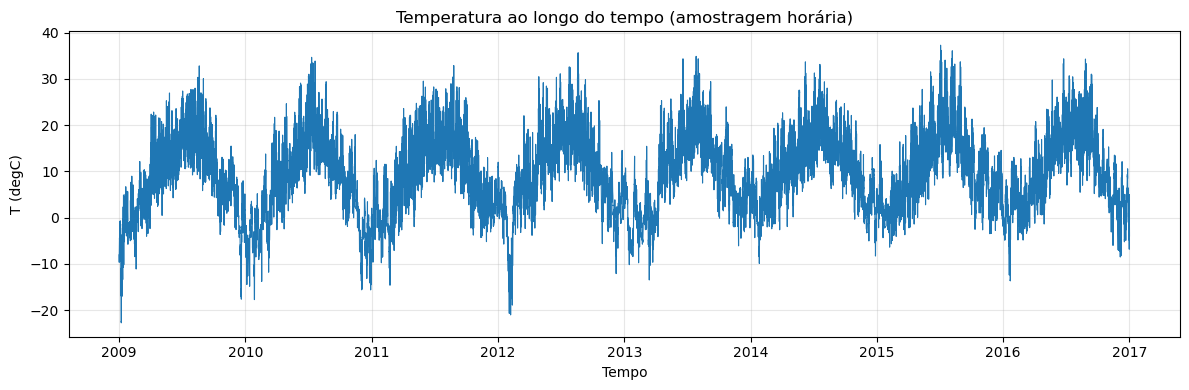

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series['Date Time'], series['T (degC)'], linewidth=0.8)
ax.set_title('Temperatura ao longo do tempo (amostragem horária)')
ax.set_xlabel('Tempo')
ax.set_ylabel('T (degC)')
ax.grid(True, alpha=0.3)
plt.tight_layout()


In [6]:
sample_size = 4000
sample = series.iloc[-sample_size:].copy()

n = len(sample)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = sample.iloc[:train_end].copy()
val_df = sample.iloc[train_end:val_end].copy()
test_df = sample.iloc[val_end:].copy()

print('Treino:    ', train_df.shape)
print('Validação: ', val_df.shape)
print('Teste:     ', test_df.shape)


Treino:     (2800, 2)
Validação:  (600, 2)
Teste:      (600, 2)


### Normalização

A normalização usa **somente estatísticas do conjunto de treino**, para evitar vazamento de informação.


In [7]:
target_col = 'T (degC)'
train_mean = train_df[target_col].mean()
train_std = train_df[target_col].std()

train_values = ((train_df[target_col] - train_mean) / train_std).to_numpy(dtype=np.float32)
val_values = ((val_df[target_col] - train_mean) / train_std).to_numpy(dtype=np.float32)
test_values = ((test_df[target_col] - train_mean) / train_std).to_numpy(dtype=np.float32)

print('Média treino:', float(train_mean))
print('Desvio treino:', float(train_std))


Média treino: 14.854392857142859
Desvio treino: 7.10612565702775


## 3. Janelamento temporal

Em vez de repetir a teoria da convolução, aqui o ponto importante é a interface entre a série temporal e a entrada de `Conv1d`.

Cada exemplo terá:

- entrada: uma janela com `lookback` observações passadas;
- alvo: a temperatura no próximo passo temporal.


In [8]:
def make_windows(values, lookback=24, horizon=1):
    X, y = [], []
    last_start = len(values) - lookback - horizon + 1
    for start in range(last_start):
        end = start + lookback
        target_idx = end + horizon - 1
        X.append(values[start:end])
        y.append(values[target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


lookback = 24
horizon = 1

train_x, train_y = make_windows(train_values, lookback=lookback, horizon=horizon)
val_x, val_y = make_windows(val_values, lookback=lookback, horizon=horizon)
test_x, test_y = make_windows(test_values, lookback=lookback, horizon=horizon)

print('train_x:', train_x.shape, 'train_y:', train_y.shape)
print('val_x:  ', val_x.shape, 'val_y:  ', val_y.shape)
print('test_x: ', test_x.shape, 'test_y: ', test_y.shape)


train_x: (2776, 24) train_y: (2776,)
val_x:   (576, 24) val_y:   (576,)
test_x:  (576, 24) test_y:  (576,)


In [9]:
example = pd.DataFrame({'lag_horas': np.arange(lookback, 0, -1), 'temperatura_normalizada': train_x[0]})
example.head()


,lag_horas,temperatura_normalizada
0,24,-0.404495
1,23,-0.345391
2,22,-0.318654
3,21,-0.334133
4,20,-0.286287


### Shape para PyTorch

`Conv1d` espera tensores no formato `(N, C, L)`. Como estamos usando apenas uma variável, `C = 1`.


In [10]:
train_x_t = torch.from_numpy(train_x).unsqueeze(1)
val_x_t = torch.from_numpy(val_x).unsqueeze(1)
test_x_t = torch.from_numpy(test_x).unsqueeze(1)

train_y_t = torch.from_numpy(train_y).unsqueeze(1)
val_y_t = torch.from_numpy(val_y).unsqueeze(1)
test_y_t = torch.from_numpy(test_y).unsqueeze(1)

print('train_x_t:', tuple(train_x_t.shape))
print('train_y_t:', tuple(train_y_t.shape))


train_x_t: (2776, 1, 24)
train_y_t: (2776, 1)


In [11]:
batch_size = 64
train_ds = TensorDataset(train_x_t, train_y_t)
val_ds = TensorDataset(val_x_t, val_y_t)
test_ds = TensorDataset(test_x_t, test_y_t)

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


## 4. Baseline e modelo Conv1d

Antes da CNN, vale estabelecer um baseline simples: prever que o próximo valor será igual ao último valor observado na janela.


In [12]:
def naive_last_value_baseline(x_windows, y_true):
    preds = x_windows[:, -1]
    mse = np.mean((preds - y_true) ** 2)
    mae = np.mean(np.abs(preds - y_true))
    return preds, mse, mae

baseline_preds, baseline_mse, baseline_mae = naive_last_value_baseline(test_x, test_y)
print('Baseline MSE (normalizado):', float(baseline_mse))
print('Baseline MAE (normalizado):', float(baseline_mae))


Baseline MSE (normalizado): 0.009894450195133686
Baseline MAE (normalizado): 0.06663362681865692


In [ ]:
class JenaConv1DRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.regressor(x)


model = JenaConv1DRegressor()
print(model)


JenaConv1DRegressor(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): ReLU()
    (10): AdaptiveAvgPool1d(output_size=1)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [14]:
def trace_shapes(model, x):
    print('input', tuple(x.shape))
    for name, module in model.features.named_children():
        x = module(x)
        print(f'features[{name}] {module.__class__.__name__:>17}: {tuple(x.shape)}')
    for name, module in model.regressor.named_children():
        x = module(x)
        print(f'regressor[{name}] {module.__class__.__name__:>10}: {tuple(x.shape)}')
    return x

_ = trace_shapes(model, torch.randn(8, 1, lookback))


input (8, 1, 24)
features[0]            Conv1d: (8, 32, 24)
features[1]       BatchNorm1d: (8, 32, 24)
features[2]              ReLU: (8, 32, 24)
features[3]         MaxPool1d: (8, 32, 12)
features[4]            Conv1d: (8, 64, 12)
features[5]       BatchNorm1d: (8, 64, 12)
features[6]              ReLU: (8, 64, 12)
features[7]         MaxPool1d: (8, 64, 6)
features[8]            Conv1d: (8, 128, 6)
features[9]              ReLU: (8, 128, 6)
features[10] AdaptiveAvgPool1d: (8, 128, 1)
regressor[0]    Flatten: (8, 128)
regressor[1]     Linear: (8, 64)
regressor[2]       ReLU: (8, 64)
regressor[3]    Dropout: (8, 64)
regressor[4]     Linear: (8, 1)


## 5. Treinamento

O objetivo aqui é um pipeline de experimento completo: laço de treino, monitoramento de treino/validação e seleção do melhor checkpoint em memória.


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print('Device:', device)


Device: cpu


In [16]:
def run_epoch(model, dataloader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    losses = []
    preds = []
    targets = []

    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(is_training):
            out = model(xb)
            loss = criterion(out, yb)
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.detach().cpu().item())
        preds.append(out.detach().cpu())
        targets.append(yb.detach().cpu())

    preds = torch.cat(preds).squeeze(1).numpy()
    targets = torch.cat(targets).squeeze(1).numpy()
    mae = np.mean(np.abs(preds - targets))
    return float(np.mean(losses)), float(mae)


In [17]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 20

history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
best_state = None
best_val_loss = float('inf')

for epoch in range(1, num_epochs + 1):
    train_loss, train_mae = run_epoch(model, train_dl, criterion, optimizer=optimizer)
    val_loss, val_mae = run_epoch(model, val_dl, criterion, optimizer=None)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_mae={train_mae:.4f} val_mae={val_mae:.4f}')

model.load_state_dict(best_state)


/Users/ebezerra/miniconda3/envs/cic1205/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 01 | train_loss=0.2434 val_loss=0.1386 train_mae=0.3833 val_mae=0.3012
Epoch 02 | train_loss=0.0953 val_loss=0.1017 train_mae=0.2400 val_mae=0.2519
Epoch 03 | train_loss=0.0601 val_loss=0.0438 train_mae=0.1871 val_mae=0.1634
Epoch 04 | train_loss=0.0501 val_loss=0.0866 train_mae=0.1734 val_mae=0.2412
Epoch 05 | train_loss=0.0441 val_loss=0.0393 train_mae=0.1616 val_mae=0.1586
Epoch 06 | train_loss=0.0354 val_loss=0.2071 train_mae=0.1439 val_mae=0.4114
Epoch 07 | train_loss=0.0435 val_loss=0.0371 train_mae=0.1610 val_mae=0.1545
Epoch 08 | train_loss=0.0407 val_loss=0.0707 train_mae=0.1544 val_mae=0.2194
Epoch 09 | train_loss=0.0348 val_loss=0.0277 train_mae=0.1421 val_mae=0.1315
Epoch 10 | train_loss=0.0307 val_loss=0.0175 train_mae=0.1320 val_mae=0.1027
Epoch 11 | train_loss=0.0274 val_loss=0.0166 train_mae=0.1247 val_mae=0.1016
Epoch 12 | train_loss=0.0309 val_loss=0.0437 train_mae=0.1343 val_mae=0.1700
Epoch 13 | train_loss=0.0310 val_loss=0.0575 train_mae=0.1325 val_mae=0.1999

<All keys matched successfully>

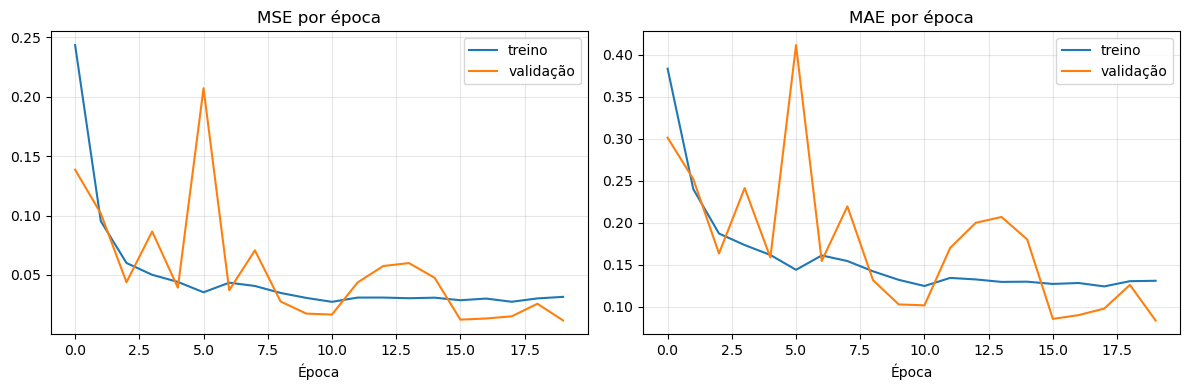

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='treino')
axes[0].plot(history['val_loss'], label='validação')
axes[0].set_title('MSE por época')
axes[0].set_xlabel('Época')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history['train_mae'], label='treino')
axes[1].plot(history['val_mae'], label='validação')
axes[1].set_title('MAE por época')
axes[1].set_xlabel('Época')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()


## 6. Avaliação no conjunto de teste

Vamos reportar métricas na escala normalizada e também na escala original da temperatura.


In [19]:
model.eval()
preds_batches = []
targets_batches = []

with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        out = model(xb).cpu()
        preds_batches.append(out)
        targets_batches.append(yb)

preds_norm = torch.cat(preds_batches).squeeze(1).numpy()
targets_norm = torch.cat(targets_batches).squeeze(1).numpy()

test_mse_norm = np.mean((preds_norm - targets_norm) ** 2)
test_mae_norm = np.mean(np.abs(preds_norm - targets_norm))

preds = preds_norm * train_std + train_mean
targets = targets_norm * train_std + train_mean
baseline = baseline_preds * train_std + train_mean

test_mse = np.mean((preds - targets) ** 2)
test_rmse = np.sqrt(test_mse)
test_mae = np.mean(np.abs(preds - targets))
baseline_mae_original = np.mean(np.abs(baseline - targets))

print(f'Test MSE  (normalizado): {test_mse_norm:.4f}')
print(f'Test MAE  (normalizado): {test_mae_norm:.4f}')
print(f'Test RMSE (degC):        {test_rmse:.4f}')
print(f'Test MAE  (degC):        {test_mae:.4f}')
print(f'Baseline MAE (degC):     {baseline_mae_original:.4f}')


Test MSE  (normalizado): 0.0098
Test MAE  (normalizado): 0.0757
Test RMSE (degC):        0.7043
Test MAE  (degC):        0.5379
Baseline MAE (degC):     0.4735


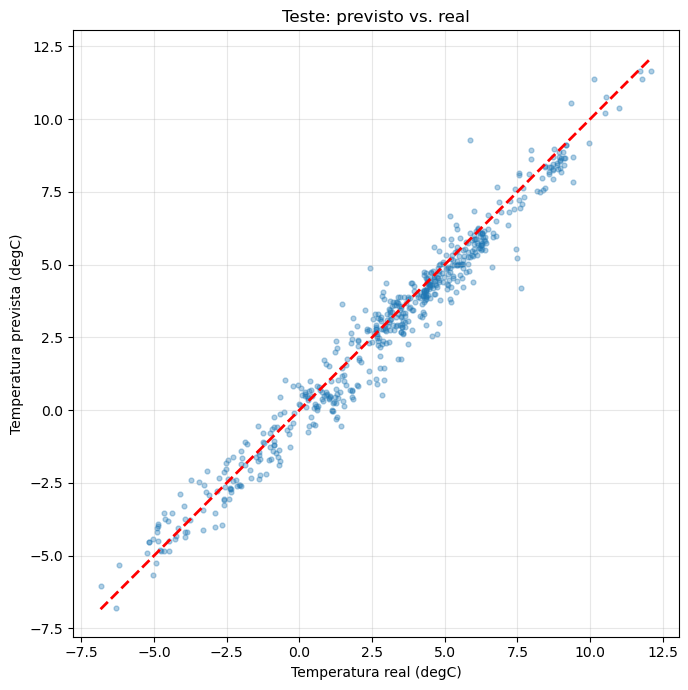

In [20]:
plt.figure(figsize=(7, 7))
plt.scatter(targets, preds, alpha=0.35, s=12)
line_min = min(np.min(targets), np.min(preds))
line_max = max(np.max(targets), np.max(preds))
plt.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)
plt.xlabel('Temperatura real (degC)')
plt.ylabel('Temperatura prevista (degC)')
plt.title('Teste: previsto vs. real')
plt.grid(True, alpha=0.3)
plt.tight_layout()


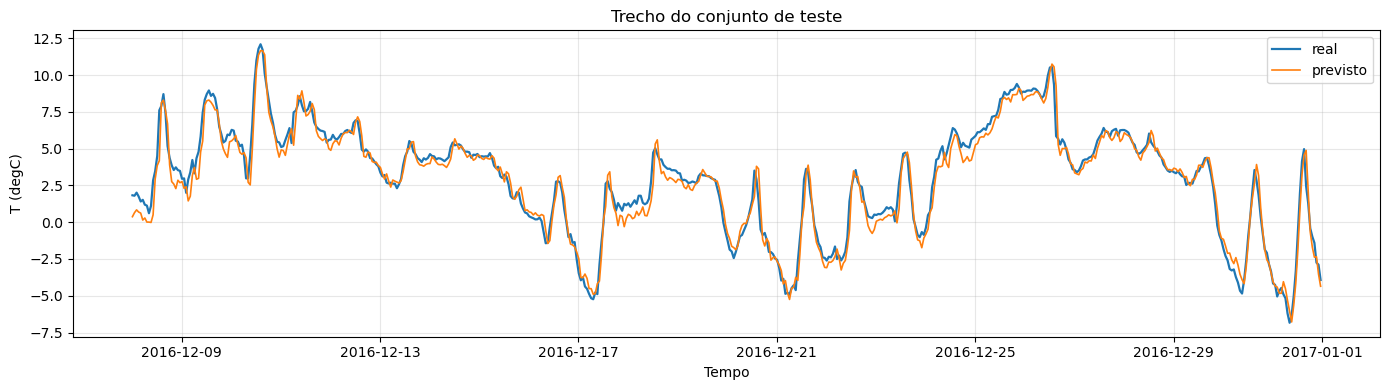

In [21]:
start = lookback + horizon - 1
plot_times = test_df['Date Time'].iloc[start:start + len(targets)]

plt.figure(figsize=(14, 4))
plt.plot(plot_times, targets, label='real', linewidth=1.6)
plt.plot(plot_times, preds, label='previsto', linewidth=1.2)
plt.title('Trecho do conjunto de teste')
plt.xlabel('Tempo')
plt.ylabel('T (degC)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


## 7. Discussão

Pontos centrais deste estudo de caso:

- `Conv1d` entra depois que o problema já foi convertido para janelas supervisionadas;
- a dimensão do canal é separada da dimensão temporal, mesmo em séries univariadas;
- um baseline ingênuo é importante para contextualizar o ganho do modelo;
- em séries temporais, treino/validação/teste devem respeitar a ordem cronológica.


## 8. Próximos passos

1. Transformar o problema em previsão **multivariada**, usando outras variáveis meteorológicas como entrada.
2. Aumentar o `lookback` para capturar ciclos diários e semanais.
3. Prever múltiplos passos à frente em vez de apenas `horizon = 1`.
4. Comparar a CNN 1D com um MLP, uma GRU/LSTM e um baseline sazonal.
